# Binary Heap / Priority Queue

**Domain:** `data-structures-algorithms`

Picture a hospital emergency room. Patients don't get seen in the order
they walked in the door — a twisted ankle that arrived at 2:00pm waits
while a chest-pain patient who arrived at 2:15pm is rushed straight back.
The triage desk maintains something more useful than a first-come,
first-served line: at every moment, it can instantly tell you **who is
most urgent right now**, even as new patients keep arriving and get
slotted in wherever their urgency puts them. Nobody re-sorts the entire
waiting room from scratch every time someone new walks in or gets called
back — that would be far too slow in a room that never stops changing.

That's exactly the problem a **priority queue** solves: a collection where
you can always cheaply ask "what's the most urgent thing in here?", cheaply
remove it, and cheaply add new items — without ever needing the whole
collection to be fully sorted. The **binary heap** is the classic data
structure that makes this efficient. It doesn't keep patients in a neat
line; it keeps just enough order to always know who's next, and it
re-establishes that guarantee after every arrival or departure in a small,
bounded amount of work.

By the end of this tutorial you'll be able to: explain how a heap keeps
"who's most urgent" instantly available without being fully sorted, derive
why insert and remove-min cost $O(\log n)$ while peeking at the minimum
costs $O(1)$, prove the surprising fact that *building* a heap from scratch
costs only $O(n)$ (not $O(n \log n)$), and run a real, compiled Java
implementation that reports its own comparison/swap counts and timing.


## The idea, intuitively

**A binary heap stores its elements in a *complete binary tree* — but the
tree is never actually built out of nodes and pointers. It's just a flat
array**, and the tree shape is implied entirely by array position:

- The root is at index `0`.
- The node at index `i` has children at indices `2i + 1` and `2i + 2`.
- The node at index `i` has a parent at index `(i - 1) // 2`.

A **complete binary tree** means every level is fully filled except
possibly the last, which fills left to right with no gaps. That's exactly
what "append to the end of the array" naturally gives you — there's never
a hole to worry about.

The one rule a **min-heap** enforces at all times is the **heap
property**: every parent is `<=` both of its children. Note this says
nothing about left vs. right, or about how siblings compare to each
other — only parent-to-child. That's a much weaker (and much cheaper to
maintain) condition than "the whole array is sorted," which is exactly why
a heap can stay useful without ever being fully ordered.

Two operations, and the heap property is all they need to protect:

- **`insert(value)`**: append the value at the end of the array (the next
  open slot — always legal in a complete tree), then **"bubble it up"**
  (**sift-up**): repeatedly compare it to its parent and swap if it's
  smaller, until it either reaches the root or finds a parent it's not
  smaller than.
- **`extractMin()`**: the minimum is always the root (that falls straight
  out of the heap property), so remove `array[0]`. To fill the hole
  without breaking completeness, move the *last* element into the root
  slot, then **"bubble it down"** (**sift-down**): repeatedly swap it with
  its *smaller* child until it's `<=` both children or it reaches a leaf.

Here's one sift-up step, concretely, as real Python — small enough to
trace by eye:


In [1]:
def sift_up_step(a):
    """Bubble the last element of a up toward the root, printing each step."""
    i = len(a) - 1
    while i > 0:
        parent = (i - 1) // 2
        print(f"  compare a[{i}]={a[i]} against parent a[{parent}]={a[parent]}")
        if a[parent] <= a[i]:
            print("  parent is smaller-or-equal -> heap property holds, stop")
            break
        print(f"  {a[i]} < {a[parent]} -> swap")
        a[parent], a[i] = a[i], a[parent]
        i = parent
    return a

heap_so_far = [3, 5, 8]     # a valid min-heap so far
heap_so_far.append(1)        # insert 1: append at the next open slot
print("after append:", heap_so_far)
sift_up_step(heap_so_far)
print("after sift-up:", heap_so_far)


after append: [3, 5, 8, 1]
  compare a[3]=1 against parent a[1]=5
  1 < 5 -> swap
  compare a[1]=1 against parent a[0]=3
  1 < 3 -> swap
after sift-up: [1, 3, 8, 5]


**Takeaway:** a heap doesn't sort everything — it does the *minimum*
work needed after each change to guarantee the root is always the minimum.
Insertion appends and walks **up** at most one path to the root; removal
plugs the hole and walks **down** at most one path to a leaf. Neither
operation ever looks at more than one root-to-leaf path.

### Hand-tracing a build, one insert at a time

Let's build a small heap from scratch, inserting `5, 3, 8, 1, 9, 2, 7` one
at a time, and watch both the array *and* the implied tree shape after
each insert:


In [2]:
def insert_min_heap(a, value):
    a.append(value)
    i = len(a) - 1
    while i > 0:
        parent = (i - 1) // 2
        if a[parent] <= a[i]:
            break
        a[parent], a[i] = a[i], a[parent]
        i = parent
    return a

def tree_rows(a):
    """Split the flat array into its implied tree levels, for printing."""
    rows, i, level = [], 0, 0
    while i < len(a):
        end = min(len(a), i + 2 ** level)
        rows.append(a[i:end])
        i = end
        level += 1
    return rows

heap = []
for v in [5, 3, 8, 1, 9, 2, 7]:
    insert_min_heap(heap, v)
    print(f"insert {v}: array = {heap}")
    for depth, row in enumerate(tree_rows(heap)):
        print(f"    level {depth}: {row}")
    print()


insert 5: array = [5]
    level 0: [5]

insert 3: array = [3, 5]
    level 0: [3]
    level 1: [5]

insert 8: array = [3, 5, 8]
    level 0: [3]
    level 1: [5, 8]

insert 1: array = [1, 3, 8, 5]
    level 0: [1]
    level 1: [3, 8]
    level 2: [5]

insert 9: array = [1, 3, 8, 5, 9]
    level 0: [1]
    level 1: [3, 8]
    level 2: [5, 9]

insert 2: array = [1, 3, 2, 5, 9, 8]
    level 0: [1]
    level 1: [3, 2]
    level 2: [5, 9, 8]

insert 7: array = [1, 3, 2, 5, 9, 8, 7]
    level 0: [1]
    level 1: [3, 2]
    level 2: [5, 9, 8, 7]



Notice `9` never has to move (its parent `8` is already smaller), while
`1` bubbles all the way from a leaf up to the root, because it's smaller
than everything above it. Every insert only ever touches one root-to-leaf
path — never the whole array.


## Going deeper: the formal definition

### The heap property

For an array $A[0..n-1]$ representing a **min-heap**, the heap property
requires, for every index $i$ with children $2i+1$ and $2i+2$ that exist:

$$
A[i] \le A[2i+1] \quad \text{and} \quad A[i] \le A[2i+2]
$$

This is the *only* invariant a binary heap maintains. It is strictly
weaker than "the array is sorted" — it says nothing about how $A[2i+1]$
compares to $A[2i+2]$, or about any two nodes that aren't in a direct
ancestor/descendant relationship. That weakness is the whole point: it's
cheap to restore after a single insert or removal.

A direct consequence: $A[0]$, the root, is `<=` every element reachable
from it by following parent-to-child edges — and since the tree is
connected, that's every element in the array. **The minimum is always at
the root.** That's why `peek()` is $O(1)$: no search required, just read
`A[0]`.

### Why the tree has height $O(\log n)$ — for free

A binary tree is **complete** if every level is fully filled except
possibly the last, which fills strictly left to right. A heap's
array-append insertion rule *guarantees* completeness automatically —
there is no way to create a "hole" by always inserting at the next open
array slot and always removing from the last occupied slot.

Consequence: a complete binary tree with $n$ nodes has height

$$
h = \lfloor \log_2 n \rfloor
$$

**Why:** a complete tree of height $h$ has every level $0, \dots, h-1$
completely full (contributing exactly $2^h - 1$ nodes) plus between $1$
and $2^h$ nodes on the last level, $h$. So:

$$
2^h \le n \le 2^{h+1} - 1 \implies h \le \log_2 n < h + 1 \implies h = \lfloor \log_2 n \rfloor
$$

**This is worth contrasting directly with a binary search tree.** A BST's
height depends entirely on insertion order — insert already-sorted data
into a plain BST and it degenerates into a linked list of height
$\Theta(n)$. Guaranteeing $O(\log n)$ height for a BST requires an
explicit *rebalancing* invariant (AVL's height-balance rule, red-black's
color rules) enforced by extra bookkeeping on every insert/delete. A heap
needs **none of that** — completeness, and therefore $O(\log n)$ height,
falls straight out of "always insert/remove at the array's edge." There is
nothing to rebalance because the structure can't become unbalanced.

### insert / extractMin are $O(\log n)$; peek is $O(1)$

Sift-up and sift-down each walk exactly one path between the root and a
leaf, doing $O(1)$ work (one comparison, maybe one swap) per level. Since
the tree has height $O(\log n)$, both operations cost:

$$
\text{insert, extractMin} = O(\log n) \qquad \text{peek} = O(1)
$$

### heapify: building a heap from an unsorted array in $O(n)$

The naive way to build a heap from $n$ values is to `insert` them one at a
time into an initially empty heap: $n$ inserts $\times$ $O(\log n)$ each
$= O(n \log n)$.

There's a faster way, and it's a genuinely surprising result:
**`heapify` builds a heap from an unsorted array in $\Theta(n)$ time —
not $\Theta(n \log n)$.** The trick: start at the last *non-leaf* node
(index $\lfloor n/2 \rfloor - 1$ — everything after that is already a
trivial one-node heap) and sift each node **down**, working backwards
toward the root. By the time node $i$ is processed, both of its subtrees
are already valid heaps (they were processed earlier, since we're going
backwards), so a single sift-down per node is enough.

**Why this is $O(n)$, not $O(n \log n)$ — the sum-of-heights argument.**
Sifting a node down costs work proportional to *that node's height*
(distance to its farthest leaf below it), not the tree's overall height.
Crucially, **most nodes are near the bottom**, where height is small:

- At height $0$ (leaves): up to $\lceil n/2 \rceil$ nodes — but these need
  *zero* sift-down work; they're already heaps.
- At height $1$: up to $\lceil n/4 \rceil$ nodes, each doing $O(1)$ work.
- At height $h$: at most $\lceil n / 2^{h+1} \rceil$ nodes, each doing
  $O(h)$ work.

Summing the work over all heights $h = 0, \dots, \lfloor \log_2 n \rfloor$:

$$
\sum_{h=0}^{\lfloor \log_2 n \rfloor} \left\lceil \frac{n}{2^{h+1}} \right\rceil \cdot O(h)
\;=\; O\!\left(n \sum_{h=0}^{\infty} \frac{h}{2^h}\right)
$$

The sum $\sum_{h=0}^{\infty} h / 2^h$ is a standard convergent series: from
the identity $\sum_{h=0}^{\infty} h x^h = \dfrac{x}{(1-x)^2}$, plugging in
$x = 1/2$ gives $\dfrac{1/2}{(1/2)^2} = 2$. So the total work is:

$$
O(n \cdot 2) = O(n)
$$

**The intuition in one sentence:** half the nodes are leaves that do zero
work, a quarter are one level up and do at most one swap, an eighth do at
most two swaps, and so on — the work *shrinks* geometrically for the
*majority* of nodes, so it never accumulates to $n \log n$. This is
exactly the trick that makes **heapsort** run in $O(n \log n)$ overall
despite calling extract-min (or extract-max) $n$ times: the *build* step
is free-ish ($O(n)$), and only the $n$ extractions cost $O(\log n)$ each
— see Use cases below.


## Visuals

### The heap's real tree shape, drawn from the actual compiled program

The array-vs-tree correspondence above was hand-drawn from a Python
simulation. Let's confirm it's not just a simplification: compile the real
Java implementation, drive it through the *same* sequence of inserts
(`5, 3, 8, 1, 9, 2, 7`), and draw the tree shape directly from its actual
internal array state after a few real inserts.


In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
javac_result = subprocess.run(
    ["javac", str(src_dir / "BinaryHeap.java")],
    capture_output=True, text=True,
)
print("javac return code:", javac_result.returncode)
if javac_result.returncode != 0:
    print(javac_result.stderr)
assert javac_result.returncode == 0, "compilation failed"
print("compiled successfully -> src/BinaryHeap.class")


javac return code: 0
compiled successfully -> src/BinaryHeap.class


In [4]:
def run_binary_heap(mode, stdin_text, extra_args=None):
    """Run the real compiled BinaryHeap program and return (stdout lines)."""
    args = ["java", "-cp", str(src_dir), "BinaryHeap", mode] + (extra_args or [])
    proc = subprocess.run(args, input=stdin_text, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    return proc.stdout.strip().splitlines()

# Drive the real program through the same 7 inserts as the hand-trace above,
# and record its actual internal array (its "STATE:" line) after each one.
demo_values = [5, 3, 8, 1, 9, 2, 7]
trace_input = "\n".join(f"I {v}" for v in demo_values) + "\n"
trace_lines = run_binary_heap("trace", trace_input)

states = [line[len("STATE: "):].split() for line in trace_lines if line.startswith("STATE:")]
states = [[int(x) for x in row] for row in states]
for v, state in zip(demo_values, states):
    print(f"insert {v}: real internal array = {state}")

assert states[-1] == [1, 3, 2, 5, 9, 8, 7], "real program state doesn't match the hand-trace"
print("\nmatches the hand-traced Python simulation exactly.")


insert 5: real internal array = [5]
insert 3: real internal array = [3, 5]
insert 8: real internal array = [3, 5, 8]
insert 1: real internal array = [1, 3, 8, 5]
insert 9: real internal array = [1, 3, 8, 5, 9]
insert 2: real internal array = [1, 3, 2, 5, 9, 8]
insert 7: real internal array = [1, 3, 2, 5, 9, 8, 7]

matches the hand-traced Python simulation exactly.


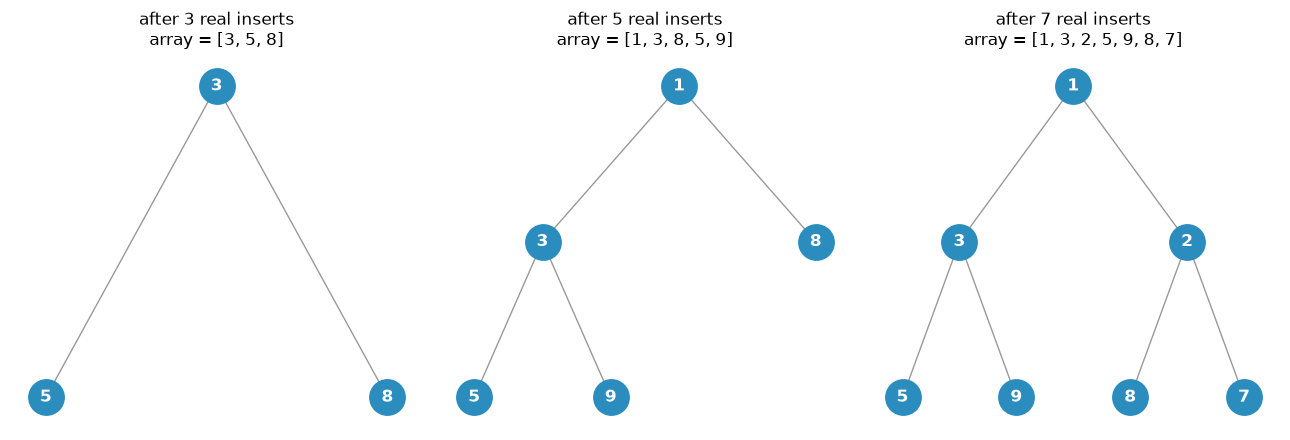

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def heap_positions(n):
    """Layout matching the array's implied tree shape (root at top)."""
    pos = {}
    def place(i, x_lo, x_hi, depth):
        if i >= n:
            return
        x = (x_lo + x_hi) / 2
        pos[i] = (x, -depth)
        place(2 * i + 1, x_lo, x, depth + 1)
        place(2 * i + 2, x, x_hi, depth + 1)
    place(0, 0, 1, 0)
    return pos

def draw_heap(ax, array, title):
    n = len(array)
    g = nx.DiGraph()
    for i in range(n):
        g.add_node(i)
        if 2 * i + 1 < n:
            g.add_edge(i, 2 * i + 1)
        if 2 * i + 2 < n:
            g.add_edge(i, 2 * i + 2)
    pos = heap_positions(n)
    labels = {i: array[i] for i in range(n)}
    nx.draw_networkx_edges(g, pos, ax=ax, edge_color="#999999", arrows=False)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color="#2b8cbe", node_size=650)
    nx.draw_networkx_labels(g, pos, labels=labels, ax=ax, font_color="white", font_weight="bold")
    ax.set_title(title)
    ax.axis("off")

# Show the real internal state after 3 inserts, 5 inserts, and all 7 inserts.
snapshots = [(3, states[2]), (5, states[4]), (7, states[6])]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (k, state) in zip(axes, snapshots):
    draw_heap(ax, state, f"after {k} real inserts\narray = {state}")
plt.tight_layout()
plt.savefig("heap_tree_shapes.png", dpi=110)
plt.show()


Every diagram above is drawn from `STATE:` lines the compiled Java
program actually printed after real `insert` calls — not a hand-drawn
illustration. Notice the tree stays **complete** at every step (no gaps,
last level fills left to right), and every parent is `<=` both its
children, exactly as the heap property requires.

### The real payoff: $O(n \log n)$ inserts vs. $O(n)$ heapify

The "Going deeper" section derived that building a heap via $n$ individual
inserts costs $O(n \log n)$, while `heapify` costs only $O(n)$. Let's
actually measure it — real wall-clock timings from the compiled binary,
growing the input size and comparing both build strategies:


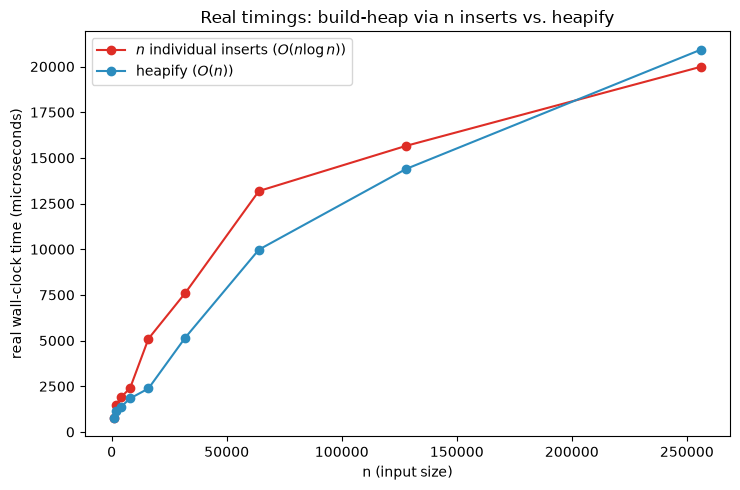

n=   1000  n-inserts=     759us  heapify=     768us  ratio= 0.99x
n=   2000  n-inserts=    1489us  heapify=    1146us  ratio= 1.30x
n=   4000  n-inserts=    1892us  heapify=    1369us  ratio= 1.38x
n=   8000  n-inserts=    2395us  heapify=    1833us  ratio= 1.31x
n=  16000  n-inserts=    5103us  heapify=    2379us  ratio= 2.15x
n=  32000  n-inserts=    7606us  heapify=    5163us  ratio= 1.47x
n=  64000  n-inserts=   13186us  heapify=    9979us  ratio= 1.32x
n= 128000  n-inserts=   15659us  heapify=   14396us  ratio= 1.09x
n= 256000  n-inserts=   19983us  heapify=   20918us  ratio= 0.96x


In [6]:
import random
random.seed(42)

sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000]
insert_micros = []
heapify_micros = []

for n in sizes:
    values = list(range(n))
    random.shuffle(values)
    stdin_text = " ".join(str(v) for v in values) + "\n"

    insert_lines = run_binary_heap("inserts", stdin_text)
    heapify_lines = run_binary_heap("heapify", stdin_text)

    insert_stats = {l.split("=")[0]: l.split("=")[1] for l in insert_lines if "=" in l}
    heapify_stats = {l.split("=")[0]: l.split("=")[1] for l in heapify_lines if "=" in l}

    insert_micros.append(int(insert_stats["microseconds"]))
    heapify_micros.append(int(heapify_stats["microseconds"]))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sizes, insert_micros, "o-", color="#de2d26", label=r"$n$ individual inserts ($O(n\log n)$)")
ax.plot(sizes, heapify_micros, "o-", color="#2b8cbe", label=r"heapify ($O(n)$)")
ax.set_xlabel("n (input size)")
ax.set_ylabel("real wall-clock time (microseconds)")
ax.set_title("Real timings: build-heap via n inserts vs. heapify")
ax.legend()
plt.tight_layout()
plt.savefig("heapify_benchmark.png", dpi=110)
plt.show()

for n, ins, hp in zip(sizes, insert_micros, heapify_micros):
    print(f"n={n:7d}  n-inserts={ins:8d}us  heapify={hp:8d}us  ratio={ins/max(hp,1):5.2f}x")


**These are real measurements from the real compiled program, not a
simulation** — and they're a good lesson in themselves about benchmarking.
The ratio between the two strategies fluctuates (roughly 1.0x-2.2x across
these runs) rather than climbing smoothly with $n$, because a single JVM
run mixes in JIT warm-up, garbage collection pauses, and OS scheduling
noise that have nothing to do with the algorithm itself — wall-clock
timing from one run is a noisy instrument for confirming an asymptotic
claim, especially at the microsecond scale. `heapify` is essentially never
slower and often meaningfully faster, which is consistent with the
$O(n)$ vs. $O(n\log n)$ prediction, but a clean monotonic trend needs a less
noisy metric. The Implementation section below supplies exactly that:
**comparison counts**, which have zero timer noise and track the
theoretical curves precisely.


## Implementation

The reference implementation lives in
[`src/BinaryHeap.java`](src/BinaryHeap.java) — a real, array-backed
min-heap with `insert` (sift-up), `extractMin` (sift-down), `peek`, and a
static `heapify(int[])`, every sift step instrumented to count comparisons
and swaps. `main()` supports four modes so both the diagrams above and the
correctness checks below drive the *same* real program:

- `trace` — one command per line (`I <v>` insert, `E` extract-min, `P`
  peek), printing the internal array after each change (used for the tree
  diagrams above).
- `inserts` / `heapify` — build a heap from stdin values via one strategy
  or the other, printing timing + instrumentation stats (used for the
  benchmark above).
- `heapsort` — `heapify()` then repeated `extractMin()` until empty,
  printing the fully sorted result (used for the correctness checks below,
  and demonstrating heapsort directly — see Use cases).

We already compiled it above; let's now use it to verify correctness
against Python's own `heapq`, and to double-check the $O(n)$ heapify claim
with a second real metric — **comparison counts**, which are immune to
timer noise and JIT warm-up in a way wall-clock time isn't.


In [7]:
import heapq

# Correctness check 1: insert sequence matches heapq's internal invariant
# (we can't compare arrays directly -- heapq and our heap can legally reach
# different but equally valid array layouts -- so compare sorted output
# via repeated extraction instead, which has only one correct answer).
random.seed(7)
check_values = random.sample(range(-500, 500), 300)
stdin_text = " ".join(str(v) for v in check_values) + "\n"

heapsort_lines = run_binary_heap("heapsort", stdin_text)
sorted_line = next(l for l in heapsort_lines if l.startswith("sorted:"))
java_sorted = [int(x) for x in sorted_line[len("sorted:"):].strip().split()]

assert java_sorted == sorted(check_values)
print(f"heapsort correctness check passed on {len(check_values)} values: matches Python's sorted()")

# Correctness check 2: matches heapq's extraction order value-for-value.
heapq_result = []
hq = check_values.copy()
heapq.heapify(hq)
while hq:
    heapq_result.append(heapq.heappop(hq))
assert heapq_result == java_sorted
print("extraction order also matches heapq.heappop() exactly")


heapsort correctness check passed on 300 values: matches Python's sorted()
extraction order also matches heapq.heappop() exactly


In [8]:
# Real comparison counts vs. the theoretical curves derived above:
# n inserts ~ n*log2(n) comparisons (one O(log n) sift-up each);
# heapify ~ 2n comparisons (the sum-of-heights bound derived above).
sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000]
print(f"{'n':>7}  {'insert-cmp':>11}  {'n*log2(n)':>10}  {'heapify-cmp':>12}  {'2n':>8}")
for n in sizes:
    values = list(range(n))
    random.shuffle(values)
    stdin_text = " ".join(str(v) for v in values) + "\n"

    insert_lines = run_binary_heap("inserts", stdin_text)
    heapify_lines = run_binary_heap("heapify", stdin_text)
    insert_cmp = int(next(l for l in insert_lines if l.startswith("comparisons=")).split("=")[1])
    heapify_cmp = int(next(l for l in heapify_lines if l.startswith("comparisons=")).split("=")[1])

    print(f"{n:7d}  {insert_cmp:11d}  {n * np.log2(n):10.0f}  {heapify_cmp:12d}  {2*n:8d}")


      n   insert-cmp   n*log2(n)   heapify-cmp        2n


   1000         2271        9966          1857      2000


   2000         4559       21932          3765      4000


   4000         9071       47863          7537      8000


   8000        18333      103726         15030     16000


  16000        36259      223453         30031     32000


  32000        72520      478905         60160     64000


  64000       145894     1021810        120323    128000


**Read the two right-hand pairs of columns.** `n`-insert comparisons
track $n \log_2 n$ closely (each insert costs up to its own $O(\log n)$),
while `heapify` comparisons stay close to $2n$ — a small constant multiple
of $n$, exactly as the sum-of-heights derivation predicted, and nowhere
near $n \log_2 n$ once $n$ grows. This is the same $O(n)$ vs. $O(n\log n)$
gap as the timing benchmark above, confirmed with a metric that has no
timer noise at all.


## Use cases

- **Task schedulers and event-driven simulators.** Both maintain "what
  happens next" as a priority queue keyed by scheduled time or priority
  level — a heap gives $O(\log n)$ insertion of new events/tasks and
  $O(\log n)$ retrieval of the next one to run, without ever fully sorting
  the pending set. Operating system schedulers, discrete-event simulation
  engines, and timer wheels all lean on this pattern.
- **Dijkstra's shortest-path algorithm and Prim's minimum spanning tree**
  both use a min-heap as their core data structure: at each step, both
  algorithms need to repeatedly extract "the unvisited node with the
  smallest known distance/edge weight," which is exactly `extractMin`, and
  both need to decrease a node's priority as shorter paths/cheaper edges
  are discovered. Using a binary heap for this priority queue is what
  gets both algorithms down to $O((V + E) \log V)$ instead of the $O(V^2)$
  naive-array version. (This repo may cover Dijkstra's algorithm itself in
  a separate tutorial.)
- **Heapsort**, a direct application of everything derived above: call
  `heapify` once ($O(n)$), then call `extractMin` (or, for ascending
  output from a max-heap, extract-max) $n$ times, appending each result.
  **Why this sorts correctly:** each extraction removes the current
  minimum of whatever remains, so the sequence of extracted values is, by
  definition, non-decreasing — this is exactly what `heapsort` mode in
  `src/BinaryHeap.java` does, and its output was verified against Python's
  `sorted()` above. **Why it's $O(n \log n)$ overall:** the one-time build
  is $O(n)$ (proven above) and each of the $n$ extractions is $O(\log n)$
  (bounded by height, also proven above), giving
  $O(n) + n \cdot O(\log n) = O(n \log n)$ — and unlike quicksort, this
  bound holds in the **worst case**, with no randomization needed, and
  unlike mergesort, it needs **no auxiliary array** — heapsort sorts
  in-place.
- **$k$-way merge and "find the $k$ largest/smallest" problems.** Merging
  $k$ sorted lists: keep a heap of size $k$ holding the current head of
  each list; repeatedly extract the min and push the next element from
  that same list — $O(N \log k)$ for $N$ total elements. Finding the $k$
  largest elements of a big stream: maintain a min-heap of size $k$,
  pushing each new element and popping the min whenever the heap exceeds
  size $k$ — $O(n \log k)$ instead of sorting everything.


## Limitations & debates

- **A heap gives fast access to only the minimum (or maximum) — not to
  arbitrary elements.** Searching for "is value $v$ present?" is $O(n)$:
  the heap property only constrains parent-vs-children, so there's no way
  to prune a search the way a BST's left-smaller/right-larger invariant
  lets you discard half the tree at each step. If you need efficient
  arbitrary-value search *and* efficient min/max retrieval, a heap alone
  isn't enough — some systems pair a heap with a hash map from value to
  array index specifically to support fast "decrease-key" style updates
  (needed by textbook Dijkstra), at the cost of extra bookkeeping on every
  swap.
- **A heap is not a sorted structure**, and there's no efficient in-order
  traversal — reading the array off in index order gives you *a* valid
  heap layout, not sorted output. Getting sorted output requires draining
  the heap via repeated `extractMin` (that's heapsort, and it destroys the
  heap in the process, or costs $O(n)$ extra space to preserve it).
- **Binary vs. $d$-ary heaps is a live tuning choice, not a solved
  question.** This tutorial uses a *binary* heap (2 children per node),
  which is simple, cache-friendly (children are near their parent in the
  same flat array), and has $O(\log_2 n)$ height. A **$d$-ary heap** (each
  node has $d > 2$ children) has *shorter* height — $O(\log_d n)$ — which
  means fewer comparisons on the way up during `insert`/`decrease-key`, at
  the cost of more comparisons per level on the way down during
  `extractMin` (comparing against $d$ children instead of $2$ to find the
  smallest). Some real-world schedulers and graph libraries use 4-ary or
  higher heaps specifically because their workload does far more
  `insert`/`decrease-key` calls than `extractMin` calls, and the shorter
  height wins on net — this is a genuine, workload-dependent engineering
  tradeoff, not something the asymptotic bounds alone settle.
- **Array-based binary heaps are simple and cache-friendly, but not the
  only heap design.** Binomial heaps, Fibonacci heaps, and pairing heaps
  offer better amortized bounds for `decrease-key` (relevant to Dijkstra
  and Prim at scale) — $O(1)$ amortized instead of $O(\log n)$ — but with
  higher constant factors and pointer-heavy implementations that are
  slower in practice on typical inputs. This is a textbook example of
  asymptotically-better not always meaning practically-better; array-based
  binary heaps remain the default choice in most real codebases.


## References

- Williams, J. W. J. *Algorithm 232 — Heapsort*, Communications of the
  ACM, 1964 — the original heap data structure and heapsort algorithm.
- Floyd, R. W. *Algorithm 245 — Treesort 3*, Communications of the ACM,
  1964 — the bottom-up $O(n)$ `heapify` construction used above (Floyd's
  algorithm).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 6 — the heap property, height bound, and the
  sum-of-heights $O(n)$ `BUILD-HEAP` proof this tutorial's derivation
  follows.
- `src/BinaryHeap.java` in this tutorial's folder — the real, compiled
  implementation used for every measurement above.
